In [2]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
## Synthetic Data


# acceleration due to gravity
acc_g = 9.8
# initial height
h0 = 5
# initial velocity
v0 = 10


def physics_based_solution(t : float ) -> float:
    return h0 + v0*t - 0.5*acc_g*(t**2)

def generate_datapoints(n : int  = 10, noise_level : float = 0.6):

    np.random.seed(7)
    max_realistic_time = (2 * v0 / acc_g) * 1.2

    time_dps = np.linspace(0, max_realistic_time, n)
    return time_dps, physics_based_solution(time_dps) + noise_level*np.random.randn(n)

In [237]:
X, Y = generate_datapoints(20,0.5)
X, Y

(array([0.        , 0.12889366, 0.25778733, 0.38668099, 0.51557465,
        0.64446831, 0.77336198, 0.90225564, 1.0311493 , 1.16004296,
        1.28893663, 1.41783029, 1.54672395, 1.67561762, 1.80451128,
        1.93340494, 2.0622986 , 2.19119227, 2.32008593, 2.44897959]),
 array([ 5.84526285,  5.97456142,  7.26865724,  8.33790931,  8.45878061,
         9.41055283,  9.80253971,  9.15627457, 10.6103045 , 10.30675047,
         9.4359994 ,  9.24233939,  8.99734978,  7.86779542,  6.96805957,
         5.29096084,  5.06020609,  3.44737773,  1.96237553, -0.66122145]))

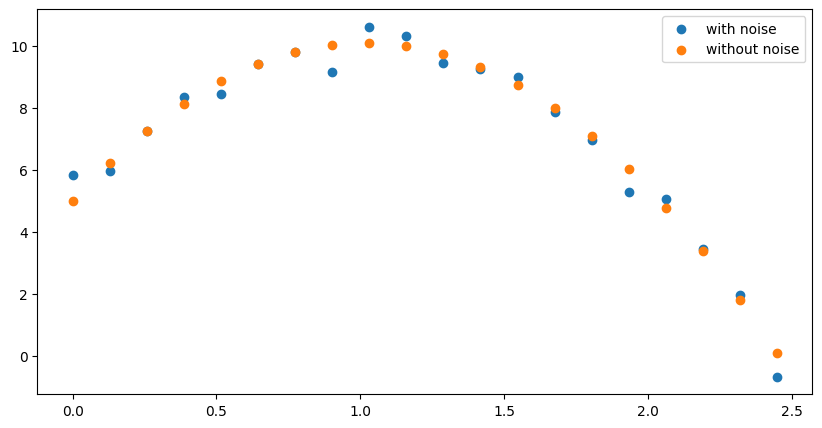

In [238]:
plt.figure(figsize=(10,5))
plt.scatter(X,Y,label='with noise')
plt.scatter(X,physics_based_solution(X),label='without noise')
plt.legend()
plt.show()

In [239]:
time_tensor = torch.tensor(X,dtype=torch.float32).view(-1,1)
height_tensor = torch.tensor(Y,dtype=torch.float32).view(-1,1)

In [240]:
class SimplePINN(nn.Module):


    def __init__(self, n_hidden):
        super(SimplePINN,self).__init__()

        self.network = nn.Sequential(

            nn.Linear(1,n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden,n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden,1)

        )

    def forward(self,t):
        return self.network(t)
    

model = SimplePINN(20)

In [241]:
mean_square_diff = lambda x : torch.mean((x)**2)


def get_derivative(y,x):

    """computes dy/dx"""

    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]



### Loss Functions


def initial_condition_loss(model):

    """ Enforces height at time 0 to be h0 defined """

    t0 = torch.zeros(1,1,dtype=torch.float32,requires_grad=False)

    h0_pred = model(t0)
    
    initial_loss = mean_square_diff(h0_pred-h0)

    return initial_loss



def physics_loss(model,t):

    """ Enforces d/dt(predicted h) to true d/dt(h) based on physics"""

    t.requires_grad_(True)
    
    h_pred = model(t)
    
    # d pred_h /dt 
    dh_dt_pred = get_derivative(h_pred,t)

    # dh/dt = derivative of ut - 1/2gt**2 -> u - gt
    dh_dt_true = v0 - acc_g*t

    loss_ode = mean_square_diff(dh_dt_pred - dh_dt_true)

    return loss_ode 


def data_point_loss(model,X,Y):

    """ MSE : Enforces predicted height to be as near to actual height"""

    y_pred = model(X)

    return mean_square_diff(y_pred-Y)



In [260]:
data_point_loss_weight = 0.2
physics_loss_weight = 1
initial_loss_weight = 1.0


optimizer = optim.Adam(model.parameters(),lr=0.01)

no_of_epochs = 5000

In [261]:
model.train()

for epoch in range(no_of_epochs):

    optimizer.zero_grad()

    dp_loss = data_point_loss(model,time_tensor,height_tensor)
    p_loss = physics_loss(model,time_tensor)
    i_loss = initial_condition_loss(model)


    total_loss = data_point_loss_weight*dp_loss + physics_loss_weight*p_loss + initial_loss_weight*i_loss

    total_loss.backward()
    optimizer.step()

    if epoch%500==0:
        print(f"Epoch [{epoch}/{no_of_epochs}] - data loss : {dp_loss:.3f} physics_loss : {p_loss:.3f} i_loss : {i_loss:.3f}")


Epoch [0/5000] - data loss : 0.032 physics_loss : 25.242 i_loss : 0.002
Epoch [500/5000] - data loss : 0.125 physics_loss : 0.000 i_loss : 0.000
Epoch [1000/5000] - data loss : 0.109 physics_loss : 0.000 i_loss : 0.000
Epoch [1500/5000] - data loss : 0.104 physics_loss : 0.000 i_loss : 0.000
Epoch [2000/5000] - data loss : 0.101 physics_loss : 0.000 i_loss : 0.000
Epoch [2500/5000] - data loss : 0.101 physics_loss : 0.000 i_loss : 0.000
Epoch [3000/5000] - data loss : 0.111 physics_loss : 0.000 i_loss : 0.000
Epoch [3500/5000] - data loss : 0.099 physics_loss : 0.000 i_loss : 0.000
Epoch [4000/5000] - data loss : 0.102 physics_loss : 0.000 i_loss : 0.000
Epoch [4500/5000] - data loss : 0.104 physics_loss : 0.000 i_loss : 0.000


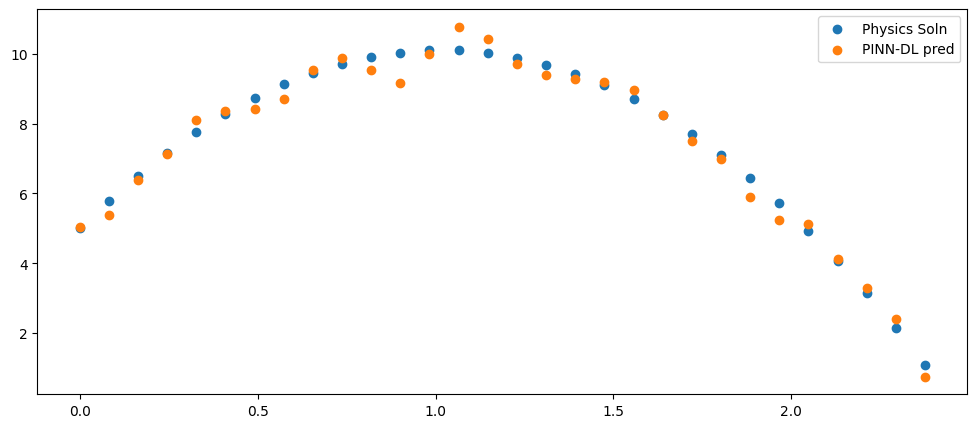

In [ ]:
## Prediction with data point loss

"""data_point_loss_weight = 1
physics_loss_weight = 0
initial_loss_weight = 1.0"""

model.eval()

test_t = torch.tensor(np.linspace(0,max(X)*0.97,30).reshape(-1,1).astype(np.float32),requires_grad=True)
test_h_pred = model(test_t)

possible_physics_soln = physics_based_solution(test_t.detach().numpy())


plt.figure(figsize=(12,5))

plt.scatter(test_t.detach().numpy(),possible_physics_soln,label='Physics Soln')
plt.scatter(test_t.detach().numpy(),test_h_pred.detach().numpy(),label='PINN-DL pred')
plt.legend()
plt.show()



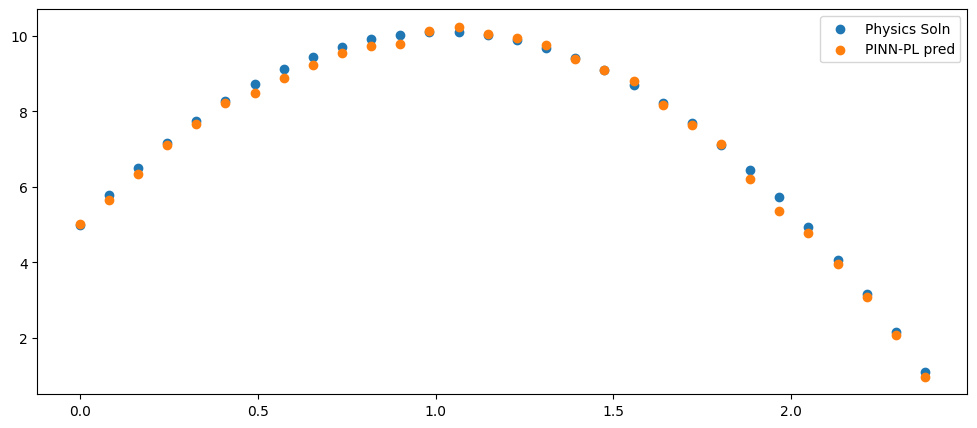

In [ ]:
## Prediction with physics loss


"""data_point_loss_weight = 0.2
physics_loss_weight = 1
initial_loss_weight = 1.0"""


model.eval()

test_t = torch.tensor(np.linspace(0,max(X)*0.97,30).reshape(-1,1).astype(np.float32),requires_grad=True)
test_h_pred = model(test_t)

possible_physics_soln = physics_based_solution(test_t.detach().numpy())


plt.figure(figsize=(12,5))

plt.scatter(test_t.detach().numpy(),possible_physics_soln,label='Physics Soln')
plt.scatter(test_t.detach().numpy(),test_h_pred.detach().numpy(),label='PINN-PL pred')
plt.legend()
plt.show()

